# Fed-SSL cross-device — um encoder só (`rnn`)

Notebook **somente de leitura**. Não treina, não escreve em `results/`.

Os mesmos resultados de `fedssl_cross_device_barras.ipynb`, restritos a **um
encoder**. Aquele notebook tem 54 figuras porque cruza 4 encoders × 5 regimes; aqui
sobram **6**, e cada uma cabe numa tela. É o mesmo dado, a mesma seleção de rodada e
a mesma paleta — só o recorte muda.

Como só existe um encoder, a segunda vista daquele notebook ("barras por encoder,
uma figura por regime") **não tem sentido aqui** e não aparece: com um encoder só,
ela seria a primeira vista com um eixo de um ponto.

**Trocar de encoder é uma linha**: a constante `ENCODER` na §1.

## Por que a `rnn`

Não é "a que tem o maior ganho" — esse argumento é frágil, porque a `rnn` tem **o
pior baseline da grade** (44,8 % com 1 rótulo, contra 68,2 % do `resnetse5`), e um
ganho medido contra uma referência ruim é em parte aritmética.

O motivo que se sustenta é outro: em **acurácia absoluta**, `rnn` + TF-C é a melhor
configuração de toda a grade a partir de 5 rótulos por classe — 79,6 % em 10 shots e
80,5 % no `full`, acima de qualquer combinação dos outros três encoders. O pré-treino
não melhora um encoder ruim: **leva o pior encoder ao topo**. A tabela da §1.2 mostra
isso, e ela existe justamente para o recorte não ser lido como escolha conveniente.

**O que este recorte esconde**, e que continua no notebook de 4 encoders:

- o TF-C **piora** o `tstcc` (−3,4 pp no `full`), resultado consistente nos três
  protocolos de seleção — não é ruído;
- no regime de **1 rótulo** a `rnn` não lidera: `resnetse5` + LFR chega a 72,5 %
  contra 68,7 % dela.

---

**Rodada reportada = média das 20 últimas.** **Barra de erro = ±1 desvio-padrão entre
as 4 seeds.** **Métrica = acurácia** (o F1-macro está desligado numa linha comentada;
quando as duas rodaram lado a lado nenhum sinal trocou).

⚠️ **F7 em aberto:** a seleção few-shot usa o split de validação **cheio** mesmo quando
o treino tem 1 rótulo por classe (`docs/metodo_e_auditoria.md`). Nada aqui corrige isso.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ENCODER = 'rnn'        # <- o unico parametro do recorte. Trocar aqui refaz o notebook.

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PART_DIR = PROJECT_ROOT / 'results' / 'fedssl_cross_device_parts'
XPART_DIR = PROJECT_ROOT / 'results' / 'fedssl_crossspec_parts'
BASE_CSV = PROJECT_ROOT / 'results' / 'fed_cross_device.csv'

# Cor segue a ENTIDADE (o metodo), nunca a posicao da barra. Paleta validada com os
# seis checks (CVD dE=9.2 no pior par sob `pairs=all`, visao normal dE=24.0). O verde
# do LFR fica em 2.74:1 contra a superficie clara — abaixo de 3:1 —, o que obriga
# legenda visivel + tabela; as duas acompanham toda figura.
CM = {'none': '#2a78d6', 'tfc': '#eb6834', 'lfr': '#1baf7a'}
LABEL = {'none': 'FedAvg supervisionado', 'tfc': 'TF-C federado', 'lfr': 'LFR federado'}
INK, INK2 = '#1a1a19', '#5c5b55'

ENCODERS = ['resnetse5', 'cnnpff', 'rnn', 'tstcc']   # so para a tabela de contexto
METHODS = ['none', 'tfc', 'lfr']
SSL = ['tfc', 'lfr']
ALL_SHOTS = ['1', '2', '5', '10', 'full']
IN_SPEC = {'RealWorld_thigh': 'device:RealWorld_thigh:10',
           'MotionSense': 'device:MotionSense:10'}
C55 = 'device:RealWorld_thigh+MotionSense:5+5'
C1010 = 'device:RealWorld_thigh+MotionSense:10+10'
ARM = {'device:RealWorld_thigh:10': 'in10-RW', 'device:MotionSense:10': 'in10-MS',
       C55: 'cross5+5', C1010: 'cross10+10'}
KEY = ['method', 'encoder', 'spec', 'seed', 'n_shots']
PAR = ['encoder', 'spec', 'seed', 'n_shots', 'target']
PLATEAU = 20

FACETAS = [('device:RealWorld_thigh:10', 'RealWorld_thigh'),
           ('device:MotionSense:10', 'MotionSense'),
           (C55, 'RealWorld_thigh'), (C55, 'MotionSense'),
           (C1010, 'RealWorld_thigh'), (C1010, 'MotionSense')]
FAC_A = [(C55, 'RealWorld_thigh'), (C55, 'MotionSense')]
FAC_O = [(sp, tg) for tg, sp in IN_SPEC.items()]

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.edgecolor': '#c9c8c2',
                     'axes.labelcolor': INK2, 'text.color': INK,
                     'xtick.color': INK2, 'ytick.color': INK2,
                     'grid.color': '#e8e7e2', 'font.size': 9,
                     'legend.frameon': False})

def style(ax):
    ax.grid(axis='y', lw=0.6)
    ax.set_axisbelow(True)
    return ax

In [2]:
raw = pd.concat([pd.read_csv(f) for f in sorted(PART_DIR.glob('*.csv'))],
                ignore_index=True)
raw['n_shots'] = raw['n_shots'].astype(str)
RMAX = int(raw['round'].max())

MET = {'acc': 'acuracia (%)'}
# MET = {'acc': 'acuracia (%)', 'f1': 'F1-macro (%)'}
RENOMEIA = {'test_acc': 'acc', 'test_f1_macro': 'f1'}

def plato(df, rmax):
    return (df[df['round'] > rmax - PLATEAU]
            .groupby(KEY + ['target'])[list(RENOMEIA)].mean()
            .rename(columns=RENOMEIA) * 100)

# `local_epochs == 5` e obrigatorio: o cache do baseline guarda tambem um braco E=1
# de calibracao (so `resnetse5`, R=100) que compararia contra outro protocolo.
b = pd.read_csv(BASE_CSV)
b = b[(b['local_epochs'] == 5) & b.spec.isin(ARM)].copy()
b['method'], b['n_shots'] = 'none', 'full'

# `todos` guarda os 4 encoders — a tabela de contexto da §1.2 precisa deles para
# situar o recorte. Todo o resto do notebook usa `dados`, ja filtrado.
todos = (pd.concat([plato(raw, RMAX), plato(b, int(b['round'].max()))])
         .reset_index())
dados = todos[todos.encoder == ENCODER].copy()

piso = (dados[dados.method == 'none'].set_index(PAR)[list(MET)]
        .rename(columns=lambda c: f'base_{c}'))
delta = dados[dados.method != 'none'].join(piso, on=PAR).dropna(subset=['base_acc'])
for m in MET:
    delta[f'd_{m}'] = delta[m] - delta[f'base_{m}']
print(f'encoder={ENCODER} | {len(dados)} celulas | {len(delta)} com par no baseline')

XLABEL = {'n_shots': 'rotulos por classe, por cliente'}

def barras(ax, d, x, ordem_x, valor, series, cores, hatch=None):
    xs, n = np.arange(len(ordem_x)), len(series)
    w = 0.82 / n
    for k, s in enumerate(series):
        g = (d[d['serie'] == s].groupby(x)[valor].agg(['mean', 'std'])
             .reindex(ordem_x))
        # w * 0.88 deixa um vao entre barras vizinhas em vez de uma borda desenhada.
        ax.bar(xs + (k - (n - 1) / 2) * w, g['mean'], w * 0.88, color=cores[s],
               hatch=(hatch or {}).get(s, ''), edgecolor='white', linewidth=0,
               yerr=g['std'], error_kw=dict(lw=0.9, ecolor=INK2, capsize=0),
               zorder=3)
    ax.set_xticks(xs)
    ax.set_xticklabels(ordem_x)
    return ax

def grade(d, valor, titulo, ylabel, series, cores, rotulos, facetas=FACETAS,
          hatch=None, zero=False, altura=2.4):
    """Um painel por (braco, alvo) — condicoes distintas nunca entram na mesma media."""
    nl = int(np.ceil(len(facetas) / 2))
    alt = altura * nl
    fig, axes = plt.subplots(nl, 2, figsize=(9.6, alt + 0.6), sharex=True, sharey=True)
    axes = np.atleast_2d(axes)
    usados = axes.ravel()[:len(facetas)]
    for ax, (spec, tgt) in zip(usados, facetas):
        style(ax)
        barras(ax, d[(d.spec == spec) & (d.target == tgt)], 'n_shots', ALL_SHOTS,
               valor, series, cores, hatch)
        if zero:
            ax.axhline(0, color=INK2, lw=1, zorder=4)
        ax.set_title(f'{ARM[spec]}  ->  alvo {tgt}', fontsize=9.5, color=INK)
    for ax in axes.ravel()[len(facetas):]:
        ax.set_visible(False)
    for ax in axes[:, 0]:
        ax.set_ylabel(ylabel, fontsize=9)
    for ax in usados[-2:]:
        ax.set_xlabel(XLABEL['n_shots'], fontsize=9)
    # Reserva vertical para a legenda ANTES do layout, senao ela cai sobre os ticks.
    folga = 0.52 / (alt + 0.6)
    fig.tight_layout(rect=[0, folga, 1, 0.95])
    fig.legend(handles=[Patch(facecolor=cores[s], hatch=(hatch or {}).get(s, ''),
                              edgecolor='white', label=rotulos[s]) for s in series],
               loc='lower center', ncol=min(3, len(series)), bbox_to_anchor=(0.5, 0.0))
    fig.suptitle(titulo, fontsize=11, y=0.995)
    plt.show()

encoder=rnn | 360 celulas | 240 com par no baseline


### 1.2 Onde a `rnn` está em relação aos outros — o contexto do recorte

Esta tabela existe para o resto do notebook não ser lido fora de contexto. Ela mostra
as duas leituras que competem: o **nível** de cada encoder sem pré-treino, e o **teto**
que cada um alcança com o melhor método.

In [3]:
ctx = todos.pivot_table(index='encoder', columns=['method', 'n_shots'], values='acc')

print('Baseline supervisionado (acc %) — a `rnn` parte de MUITO abaixo:')
display(ctx['none'].reindex(index=ENCODERS, columns=ALL_SHOTS).round(1))

print('\nMelhor metodo de cada encoder (acc %) — e chega ao TOPO:')
melhor = (todos.groupby(['encoder', 'method', 'n_shots'])['acc'].mean()
          .reset_index())
top = melhor.loc[melhor.groupby(['encoder', 'n_shots'])['acc'].idxmax()]
display(top.pivot_table(index='encoder', columns='n_shots', values='acc',
                        aggfunc='max').reindex(index=ENCODERS,
                                               columns=ALL_SHOTS).round(1))
print('(qual metodo vence em cada celula)')
display(top.pivot_table(index='encoder', columns='n_shots', values='method',
                        aggfunc='first').reindex(index=ENCODERS, columns=ALL_SHOTS))

Baseline supervisionado (acc %) — a `rnn` parte de MUITO abaixo:


n_shots,1,2,5,10,full
encoder,,,,,
resnetse5,68.2,69.7,70.3,70.6,69.7
cnnpff,60.1,66.8,72.2,74.2,74.8
rnn,44.8,50.9,55.1,56.6,64.7
tstcc,58.9,64.4,69.8,71.8,75.2



Melhor metodo de cada encoder (acc %) — e chega ao TOPO:


n_shots,1,2,5,10,full
encoder,,,,,
resnetse5,72.5,72.9,72.3,73.5,73.4
cnnpff,65.5,72.6,75.9,77.6,79.1
rnn,68.7,74.2,77.4,79.6,80.5
tstcc,60.7,67.3,73.3,75.1,78.0


(qual metodo vence em cada celula)


n_shots,1,2,5,10,full
encoder,,,,,
resnetse5,lfr,lfr,lfr,tfc,tfc
cnnpff,tfc,tfc,tfc,tfc,tfc
rnn,tfc,tfc,tfc,tfc,tfc
tstcc,lfr,lfr,lfr,lfr,lfr


## 2. A ladder de rótulos

Acurácia de teste bruta. Um painel por (braço × alvo) — os 4 braços são condições
experimentais distintas e não devem ser mediados juntos; os specs mistos rendem 2
alvos cada, daí 6 painéis.

Três barras por grupo: o baseline supervisionado e os dois métodos de pré-treino.

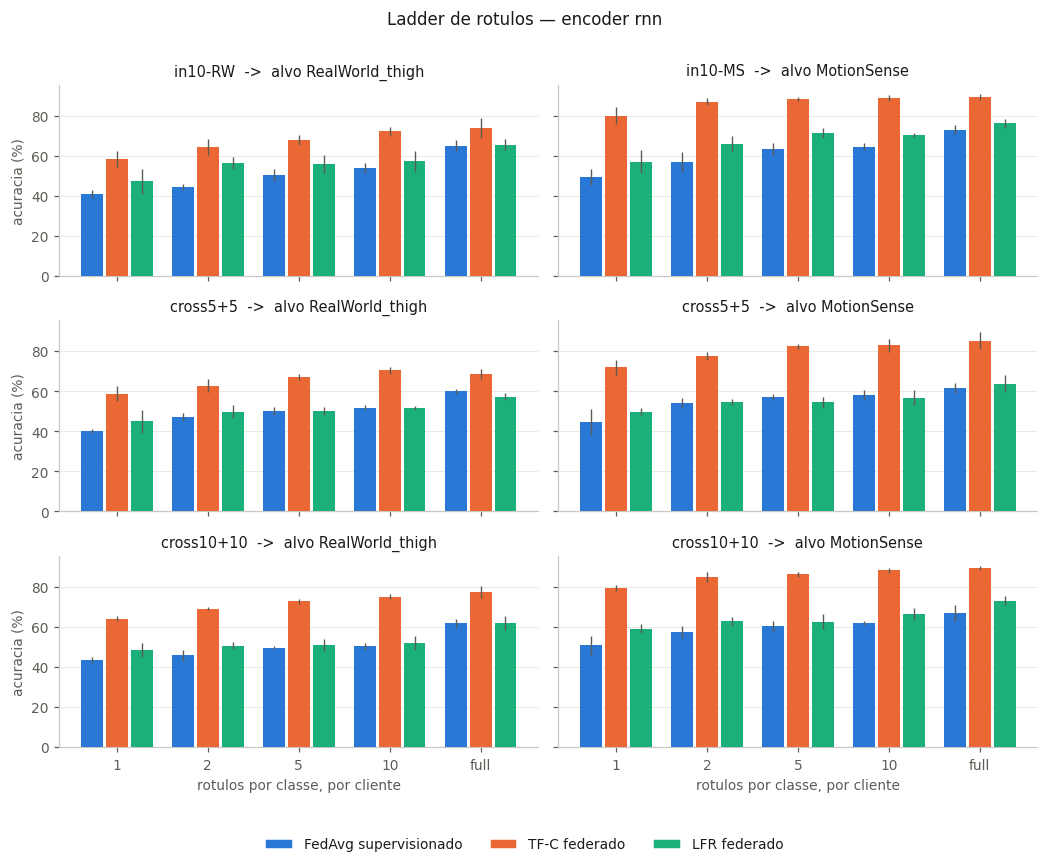

In [4]:
d = dados.assign(serie=dados.method)
for met, ylab in MET.items():
    grade(d, met, f'Ladder de rotulos — encoder {ENCODER}', ylab,
          METHODS, CM, LABEL)

## 3. O ganho do SSL sobre o supervisionado (Δ)

O mesmo, com o baseline subtraído **dentro de cada seed** — não é média menos média.
Some a barra azul e o zero vira a referência: acima dele o pré-treino ajudou.

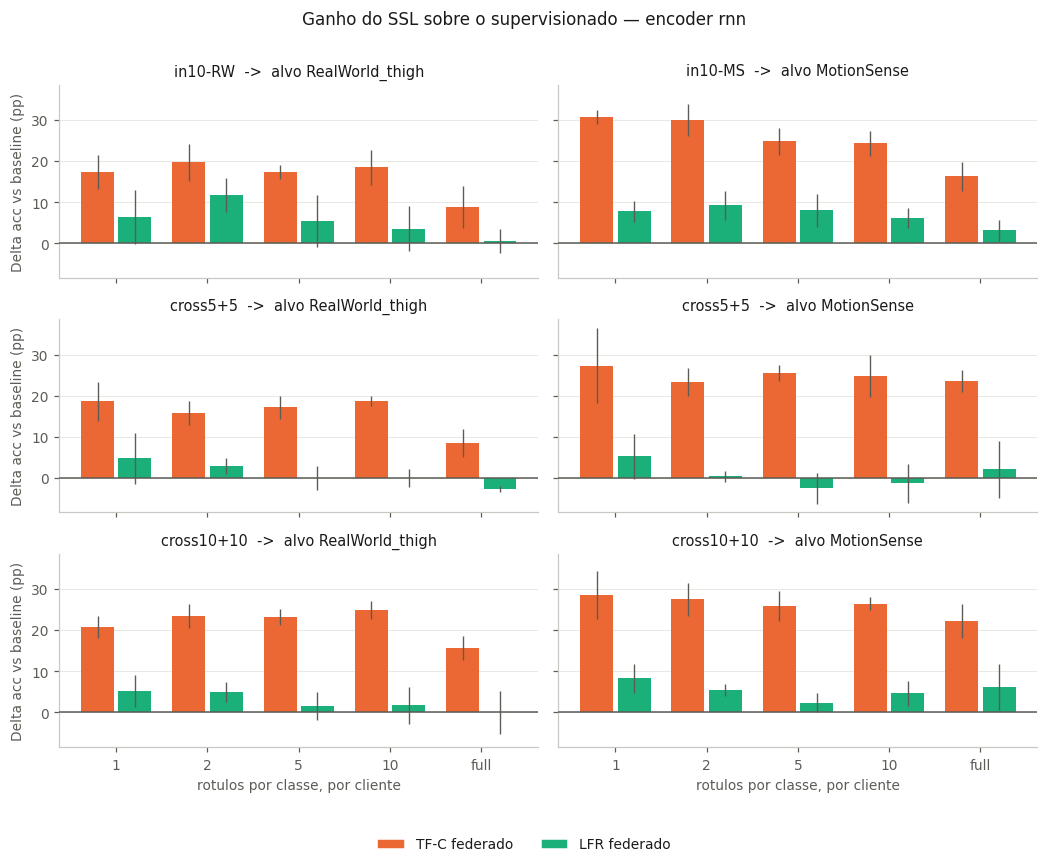

Delta medio (pp), agregado sobre bracos e alvos — CONFERENCIA da figura:


d_acc                        
           1     2     5    10  full
method                              
lfr      6.3   5.7   2.5   2.4   1.6
tfc     23.9  23.3  22.3  22.9  15.9

In [5]:
dl = delta.assign(serie=delta.method)
for met in MET:
    grade(dl, f'd_{met}',
          f'Ganho do SSL sobre o supervisionado — encoder {ENCODER}',
          f'Delta {met} vs baseline (pp)', SSL, CM, LABEL, zero=True)

print('Delta medio (pp), agregado sobre bracos e alvos — CONFERENCIA da figura:')
display(dl.pivot_table(index='method', columns='n_shots',
                       values=[f'd_{m}' for m in MET])
        .reindex(columns=pd.MultiIndex.from_product(
            [[f'd_{m}' for m in MET], ALL_SHOTS])).round(1))

## 4. Δ A — o ganho do SSL **dentro** do cenário cross-domain

Braço fixo em `cross5+5`, onde os clientes vêm de dois datasets diferentes. É a
leitura de **deployment**: *"vou operar uma federação com clientes de domínios
diferentes — o pré-treino ajuda?"* Não precisa de controle nenhum.

Um painel por alvo, porque o custo do shift não é simétrico entre os dois.

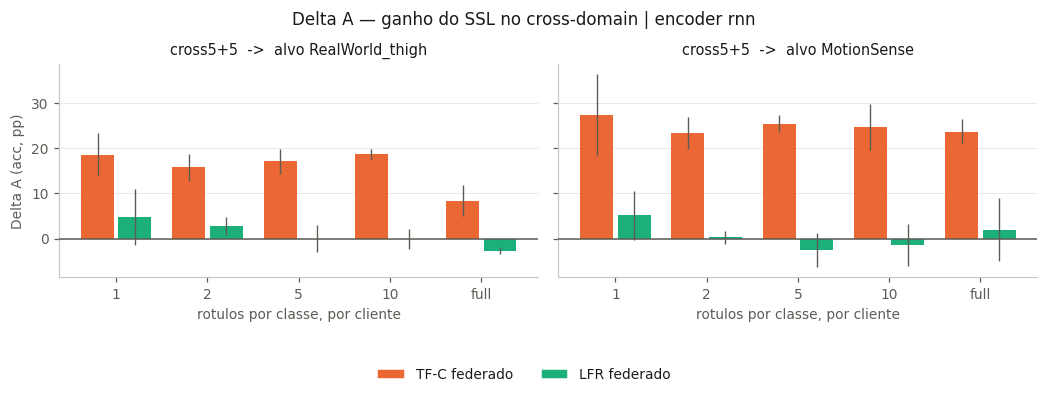

In [6]:
for met in MET:
    grade(dl, f'd_{met}',
          f'Delta A — ganho do SSL no cross-domain | encoder {ENCODER}',
          f'Delta A ({met}, pp)', SSL, CM, LABEL, facetas=FAC_A, zero=True,
          altura=2.9)

## 5. Ganho no cross-domain − ganho no in-domain

*(era o "DiD")*

O Δ A sozinho **não** diz que o SSL ataca o domain shift. Se o pré-treino for
uniformemente melhor, o Δ A é grande sem que o custo do shift mude — e é exatamente
o caso desta `rnn`: o ganho no cross-domain é enorme, mas o ganho no in-domain é
ainda maior. O SSL aqui está consertando o **encoder**, não o **shift**.

```
ganho_cross  = acc(cross5+5, SSL) - acc(cross5+5, supervisionado)
ganho_in     = acc(in-domain, SSL) - acc(in-domain, supervisionado)
diferenca    = ganho_cross - ganho_in
```

**> 0** = rende mais justamente onde há shift. **≈ 0** = rende igual nos dois cenários.

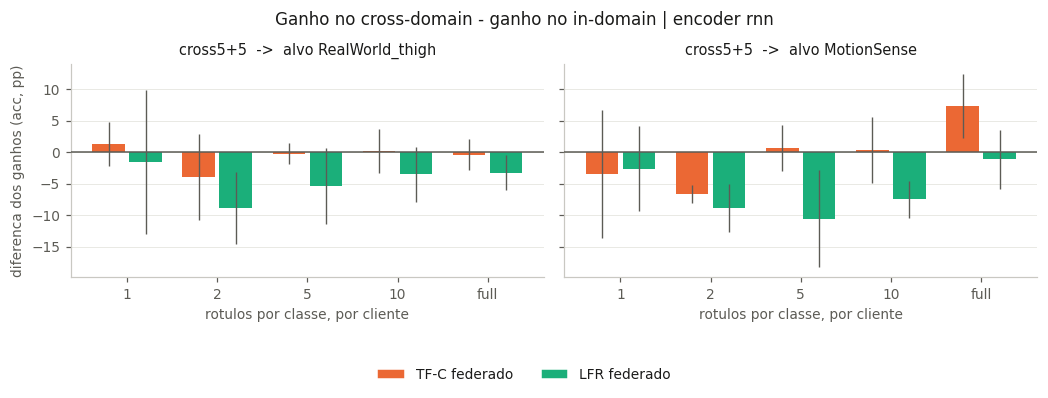

Media da diferenca (pp) — CONFERENCIA. Exploratorio: sao 20 celulas
(2 metodos x 5 degraus x 2 alvos) com 4 seeds cada.


dif_acc                    
             1    2    5   10 full
method                            
lfr       -2.1 -8.9 -8.0 -5.5 -2.2
tfc       -1.1 -5.3  0.2  0.3  3.5

In [7]:
IDX = ['method', 'seed', 'n_shots', 'target']
dl2 = dl.assign(in_spec=dl.target.map(IN_SPEC))
COLS = [f'd_{m}' for m in MET]
cross = (dl2[dl2.spec == C55].set_index(IDX)[COLS]
         .rename(columns=lambda c: f'{c}_cross'))
indom = (dl2[dl2.spec == dl2.in_spec].set_index(IDX)[COLS]
         .rename(columns=lambda c: f'{c}_in'))
dif = pd.concat([cross, indom], axis=1).dropna()
for met in MET:
    dif[f'dif_{met}'] = dif[f'd_{met}_cross'] - dif[f'd_{met}_in']
dif = dif.reset_index()
dif['serie'] = dif.method
dif['spec'] = C55                     # so para reusar a `grade`; o painel e o alvo

for met in MET:
    grade(dif, f'dif_{met}',
          f'Ganho no cross-domain - ganho no in-domain | encoder {ENCODER}',
          f'diferenca dos ganhos ({met}, pp)', SSL, CM, LABEL, facetas=FAC_A,
          zero=True, altura=2.9)

print('Media da diferenca (pp) — CONFERENCIA. Exploratorio: sao 20 celulas\n'
      '(2 metodos x 5 degraus x 2 alvos) com 4 seeds cada.')
display(dif.pivot_table(index='method', columns='n_shots',
                        values=[f'dif_{m}' for m in MET])
        .reindex(columns=pd.MultiIndex.from_product(
            [[f'dif_{m}' for m in MET], ALL_SHOTS])).round(1))

## 6. O backbone precisa ter sido pré-treinado no domínio do alvo?

Nos braços anteriores, pré-treino e fine-tuning usavam **a mesma gente**. Aí não dá
para saber se o ganho vem de a representação ser boa ou de ela ter sido feita sob
medida para aquelas pessoas.

Aqui o fine-tuning é **idêntico** nos três casos (os mesmos 10 usuários do alvo, os
mesmos rótulos, as mesmas 150 rodadas). Só a origem do backbone muda:

| barra | pré-treino |
|---|---|
| **FedAvg supervisionado** (azul) | nenhum — pesos aleatórios |
| **próprio domínio** (lisa) | 10 usuários **do alvo** |
| **outro domínio** (hachurada) | 10 usuários **do outro dataset** |

As duas barras coloridas de cada método têm a **mesma cor de propósito** — é o mesmo
método, e cor identifica método em todo o notebook. O que as separa é a hachura.

Só os dois braços in-domain aparecem: pré-treinar "no outro domínio" não é definível
para um braço que já mistura os dois.

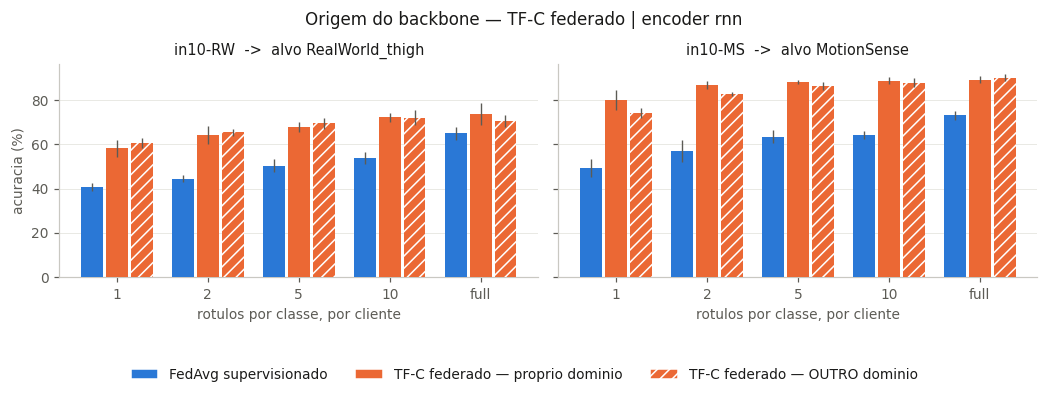

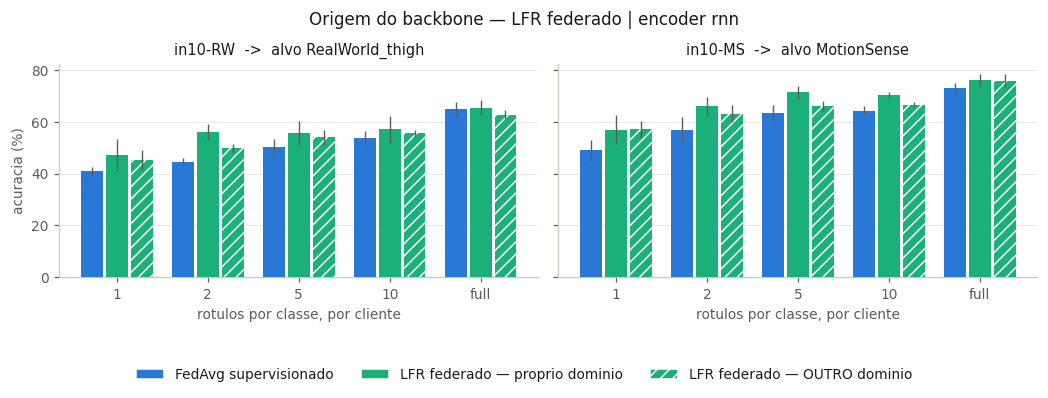

Media por origem do backbone (acc %) — CONFERENCIA:


serie,lfr_outro,lfr_proprio,none,tfc_outro,tfc_proprio
n_shots,,,,,
1,51.2,52.1,45.0,67.5,69.1
2,56.6,61.1,50.7,74.0,75.5
5,60.0,63.6,56.8,77.9,77.9
10,61.1,63.8,59.0,80.0,80.4
full,69.4,70.8,68.9,80.4,81.5


In [8]:
# `pre-device-*` = backbone feito no OUTRO dominio. O irmao `pre-single-*` (Exp. 2,
# backbone num cliente so) mora em outra pasta e responde outra pergunta.
xdev = pd.concat([pd.read_csv(f)
                  for f in sorted(XPART_DIR.glob('pre-device-*/*.csv'))],
                 ignore_index=True)
xdev['n_shots'] = xdev['n_shots'].astype(str)
xd = plato(xdev, int(xdev['round'].max())).reset_index()
xd = xd[xd.encoder == ENCODER]

SIMPLE = list(IN_SPEC.values())
orig = pd.concat([
    dados[(dados.method == 'none') & dados.spec.isin(SIMPLE)].assign(serie='none'),
    dados[dados.method.isin(SSL) & dados.spec.isin(SIMPLE)]
        .assign(serie=lambda x: x.method + '_proprio'),
    xd.assign(serie=lambda x: x.method + '_outro'),
], ignore_index=True)

for met, ylab in MET.items():
    for m in SSL:
        ser = ['none', f'{m}_proprio', f'{m}_outro']
        cores = {'none': CM['none'], f'{m}_proprio': CM[m], f'{m}_outro': CM[m]}
        hat = {f'{m}_outro': '///'}
        rot = {'none': LABEL['none'],
               f'{m}_proprio': f'{LABEL[m]} — proprio dominio',
               f'{m}_outro': f'{LABEL[m]} — OUTRO dominio'}
        grade(orig[orig.serie.isin(ser)], met,
              f'Origem do backbone — {LABEL[m]} | encoder {ENCODER}', ylab,
              ser, cores, rot, facetas=FAC_O, hatch=hat, altura=2.9)

print('Media por origem do backbone (acc %) — CONFERENCIA:')
display(orig.pivot_table(index='n_shots', columns='serie', values='acc')
        .reindex(ALL_SHOTS).round(1))

## 7. Ressalvas — ler antes de citar qualquer número daqui

1. **Um encoder não é a grade.** Este recorte mostra o melhor caso. O `tstcc` sofre
   **dano** com o TF-C (−3,4 pp no `full`) e o `resnetse5` fica em ~0 — os dois estão
   em `fedssl_cross_device_barras.ipynb`. Citar a `rnn` como se fosse o resultado do
   método, e não o melhor caso dele, é o erro que este notebook mais facilita.
2. **O ganho de +24 pp é medido contra o pior baseline da grade.** A afirmação que
   sobrevive à pergunta "e o baseline?" é *"o TF-C leva o pior encoder ao topo"*
   (§1.2), não *"o TF-C dá +24 pp"*.
3. **O §5 não sustenta "mitiga domain shift".** O custo do shift no baseline vai de
   −0,7 a −9,8 pp na grade toda, e só um par passa de −5 — pouca dinâmica para medir.
4. **O `cross10+10` não é "dado estrangeiro vale tanto quanto dado próprio".** Ele tem
   20 clientes contra 10 do `in10-RW`; não existe federação de 20 clientes só de
   RW_thigh (a base tem 10 usuários). O Δ dele é "acrescentar um segundo domínio".
5. **F7.** Seleção few-shot na validação cheia (ver topo). Afeta todos os braços
   igualmente, então provavelmente não inverte um Δ — mas infla o nível absoluto.
6. **O degrau `full` do baseline vem de outra grade** (`fed_cross_device.csv`,
   filtrada em `local_epochs == 5`). Mesmo protocolo — R=150, budget 192, seeds 0–3 —,
   mas não foi executado no mesmo mutirão que o resto.